In [1]:
import numpy as np
import pandas as pd
import random
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report
from itertools import product
import statsmodels.api as sm

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe
from utils import plot_roc_curve, plot_pr_curve, plot_probability_curve

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

# file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
# file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
# file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'

# dataset1 = read_data(file1)
dataset2 = read_data(file2)
# dataset3 = read_data(file3)
# dataset4 = read_data(file4)


# dataset1.head()

dataset2.head()

# dataset3.head()

# dataset4.head()

# dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])
dataset = dataset2

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(504, 112)


In [2]:
dataset.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL611,2010,1,21.720538,39.507246,0.344330,0.131772,-0.164562,-0.131772,0.351663,0.138953,-0.161584,-0.138953,0.072157,0.073429,0.095126,0.073429,10.324867,4.699393,7.541364,13.255044,13.255044,3.412974,1.761039,0.200398,1.498356,1.498356,6.868921,3.230216,3.870881,7.395288,7.395288,1.743648,14.674717,9.513972,36.701100,124.217848,292.411665,2058.948979,738.424528,23.820146,14.958333,20.083333,37.893082,917.372318,41.0,-12.0,53.0,5.666667,25.166667,25.833333,3.833333,2052.0,406.0,45.0,69.435433,971.0,166.0,200.0,839.0,31,36,30,12,12,1,6,7,27200.472304,1274.356805,14.386792,157.112436,592.606883,176.446743,0.009971,193.019621,0.000000,10.738235,0,0.000000,85.575241,111.425738,0.0,1.0,48533.184371,3761.225463,48,301.668176,1729.069187,225.100972,2.584467,17465.615896,11744.675930,845.696425,11.675884,54.646084,479.172670,16.464355,0.147294,1426.627793,17466.0,77268.0,28083.0,122817.0,17105.0,74553.0,35419.0,127077.0,3296.18,10352.0,10375.0,0
1,EL612,2010,1,22.407574,39.702044,0.263468,-0.034510,-0.273834,0.034510,0.249646,-0.036767,-0.264302,0.036767,0.058782,0.058005,0.042991,0.058005,12.333341,6.793895,10.575814,16.242166,16.242166,4.519342,1.699212,0.966283,2.243861,2.243861,8.426342,4.246554,5.771048,9.243013,9.243013,2.268996,16.713441,9.078019,35.835411,107.246464,280.483500,1454.989694,769.064516,24.808533,17.250000,22.166667,45.238095,931.640781,45.0,-4.0,49.0,8.333333,28.833333,28.833333,6.333333,1448.0,281.0,37.0,67.310943,640.0,170.0,170.0,594.0,31,36,30,12,12,1,6,7,20414.827110,1389.449186,9.451613,167.429332,377.276885,180.754471,0.000097,876.660925,807.833526,3.470693,0,48.757971,2.749400,139.798569,0.0,1.0,44144.763000,4948.782933,41,313.201073,1991.780135,232.043865,0.009690,54053.002191,10790.412304,1051.699053,9.369147,54.061533,360.465176,11.577150,0.000789,5878.363151,23291.0,94577.0,25594.0,143462.0,22117.0,93495.0,30638.0,146250.0,5066.81,7604.0,8362.0,0
2,EL613,2010,1,22.862978,39.279998,0.322976,0.136636,-0.129853,-0.136636,0.309199,0.148988,-0.100460,-0.148988,0.043004,0.048798,0.061535,0.048798,12.159471,6.264925,9.527607,14.859624,14.859624,6.342837,2.651805,1.864013,3.901596,3.901596,9.251154,4.458365,5.695810,9.380610,9.380610,3.658866,16.772062,9.868127,44.910923,82.850549,304.801321,1435.288760,517.865979,16.705354,16.833333,19.500000,44.318182,847.277279,42.0,-2.0,44.0,9.000000,27.500000,27.500000,7.166667,1428.0,305.0,22.0,74.352423,644.0,122.0,122.0,473.0,31,20,30,12,12,1,6,1,7789.380127,1589.723252,10.835052,172.793705,387.960979,179.933352,0.000222,16.409124,493.305640,59.481798,0

In [3]:
dataset = encode_cyclical(dataset, 'month', 12)

In [4]:
dataset.cases.sum()

210

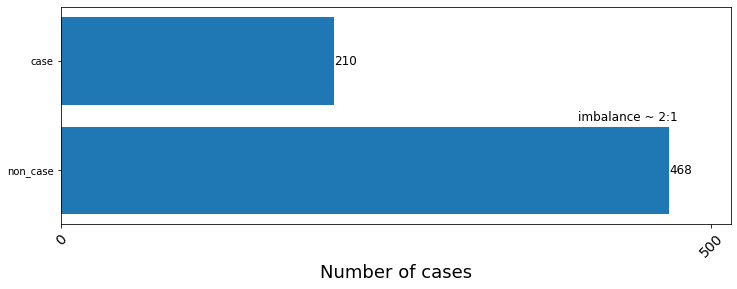

In [5]:
plot_imbalance(dataset, target_column='cases')

In [6]:
#dataset = dataset.query('month >= 5 & month <= 11')
dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

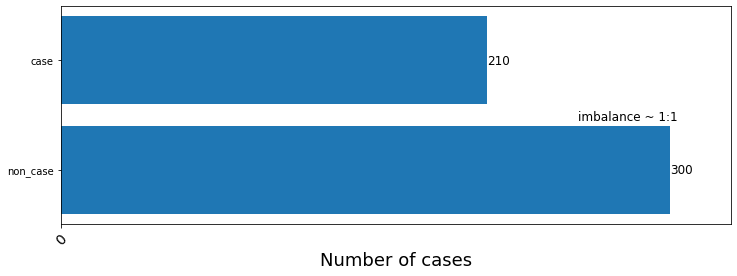

In [7]:
plot_imbalance(dataset, target_column='cases')

In [8]:
dataset.shape

(336, 114)

In [9]:
dataset.cases.sum()

210

In [10]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,21,9,30,2.33%
1,2011,17,30,47,0.57%
2,2012,24,0,24,inf%
3,2013,24,0,24,inf%
4,2014,24,0,24,inf%
5,2015,24,0,24,inf%
6,2016,24,0,24,inf%
7,2017,24,0,24,inf%
8,2018,22,7,29,3.14%
9,2019,18,53,71,0.34%


In [11]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [12]:
n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
#k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [13]:
features_to_remove = ['bio16', 'lst_mean', 'month_cos', 'slope_mean_1km_max',
       'distance_to_river_max', 'aspect_mean_200m_max',
       'elevation_mean_1km_std', 'elevation_mean_1km_max',
       'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max',
       'distance_to_coast_max', 'distance_to_coast_std', 'flow_accu_200m_min',
       'distance_to_river_std', 'slope_mean_1km_std', 'fs_area_1km_min',
       'aspect_mean_200m_std', 'flow_accu_200m_std', 'hillshade_mean_1km_std',
       'fs_area_1km_std', 'elevation_mean_1km_min', 'males_lt15', 'ndbi_std',
       'ndbi_mean', 'males_total', 'females_lt15', 'females_15t64',
       'ndwi_mean', 'females_total', 'ndvi_mean', 'unl_total', 'ndbi',
       'hillshade_mean_1km_min', 'lst_apr_mean', 'aspect_mean_200m_min',
       'lc_prop3', 'lst_feb_mean', 'bio2', 'bio5', 'bio6', 'bio7', 'bio8',
       'lst_mar_night_mean', 'bio12', 'lst_jan_night_mean', 'lst_apr_day_mean',
       'lst_mar_day_mean', 'bio17', 'ndmi', 'lc_prop1', 'lc_type1',
       'slope_mean_1km_min', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5',
       'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'lst_mar_mean',
       'distance_to_river_min', 'distance_to_coast_min', 'bio3', 'l_total']


features_to_remove = features_to_remove + ['x', 'y', 'year', 'month']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

['ndvi', 'ndwi', 'ndmi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_night_mean', 'lst_feb_night_mean', 'lst_apr_night_mean', 'lst_jan_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio4', 'bio9', 'bio10', 'bio11', 'bio13', 'bio14', 'bio15', 'bio18', 'bio19', 'lc_prop2', 'males_15t64', 'males_gt65', 'females_gt65', 'mio_eur', 'month_sin']


In [14]:
print(f"Total Features Used: {len(feature_names)}")

Total Features Used: 38


In [15]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train = convert_multiple_cases(data_train, target_col='cases')
    #data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.1,
        "min_split_loss": 0.5,
        "max_depth": 3, 
        "reg_alpha": 0.5,
        "reg_lambda": 0.5,
        "min_child_weight": 1.5,
        "scale_pos_weight": sum_negatives/sum_positives, 
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(data_train['cases'].value_counts().get(0) / data_train['cases'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases'].value_counts().get(0) / data_test['cases'].value_counts().get(1)):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    #scaler = RobustScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/10
Training set 0/1 Ratio: 1.40
Test set 0/1 Ratio: 7.50
Weight: 1.40
Fold: 2/10
Training set 0/1 Ratio: 1.40
Test set 0/1 Ratio: 7.50
Weight: 1.40
Fold: 3/10
Training set 0/1 Ratio: 1.53
Test set 0/1 Ratio: 7.50
Weight: 1.53
Fold: 4/10
Training set 0/1 Ratio: 1.48
Test set 0/1 Ratio: 7.50
Weight: 1.48
Fold: 5/10
Training set 0/1 Ratio: 1.42
Test set 0/1 Ratio: 7.50
Weight: 1.42
Fold: 6/10
Training set 0/1 Ratio: 1.41
Test set 0/1 Ratio: 7.50
Weight: 1.41
Fold: 7/10
Training set 0/1 Ratio: 1.33
Test set 0/1 Ratio: 10.00
Weight: 1.33
Fold: 8/10
Training set 0/1 Ratio: 1.36
Test set 0/1 Ratio: 10.00
Weight: 1.36
Fold: 9/10
Training set 0/1 Ratio: 1.48
Test set 0/1 Ratio: 10.00
Weight: 1.48
Fold: 10/10
Training set 0/1 Ratio: 1.50
Test set 0/1 Ratio: 10.00
Weight: 1.50


In [16]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [17]:
df_test = pd.DataFrame({'score': y_test_proba[:, 1], 'target': y_test_true})

In [18]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0357
Test Loss: 0.1687


In [19]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_test_proba[:,1], y_test_true, beta = 1, round_factor = 2)
print(classification_thresholds)

0.3


In [20]:
thr = classification_thresholds

In [21]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

In [22]:
print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       300
           1       0.63      0.75      0.68        36

    accuracy                           0.93       336
   macro avg       0.80      0.85      0.82       336
weighted avg       0.93      0.93      0.93       336



In [23]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[284  16]
 [  9  27]]


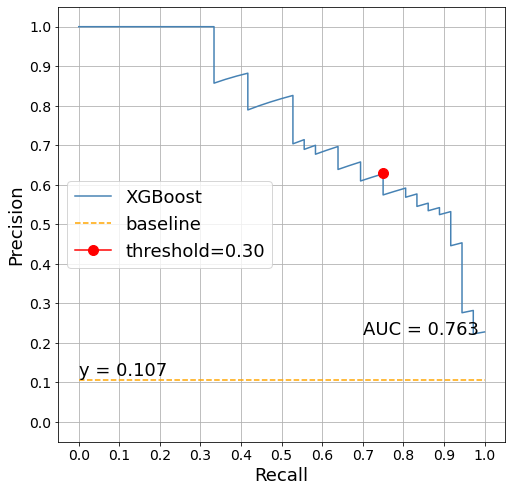

(0.75, 0.63, 0.6835, 0.3)

In [24]:
plot_pr_curve(df_test, target_col = 'target', model_name='XGBoost', plot_fbeta=True, beta = 1)

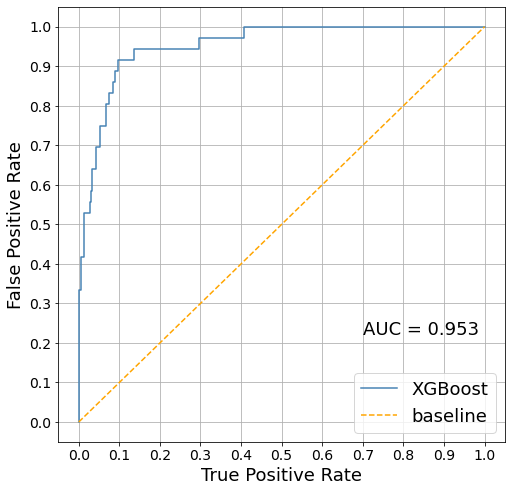

(0.0967, 0.9167, 0.91, 0.1614)

In [25]:
plot_roc_curve(df_test, target_col = 'target', model_name='XGBoost')

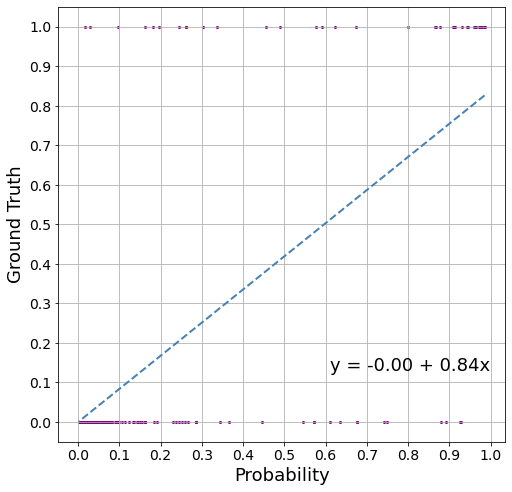

(-0.00020575057902745366, 0.8387186699795408)

In [26]:
plot_probability_curve(df_test, target_col = 'target', marker_size=4, marker_shape='o')

In [27]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)


In [28]:
# Tree explainer

# curently not working with multioutput models

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

In [29]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']

tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index


In [30]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Tree_Shapely_Values.npz'

# np.savez(shap_values_path, *tree_shap_values)

# # shap_values = []
# # loaded_shap_values = np.load(shap_values_path)

# # for key in loaded_shap_values.keys():
# #     shap_values.append(loaded_shap_values[key])

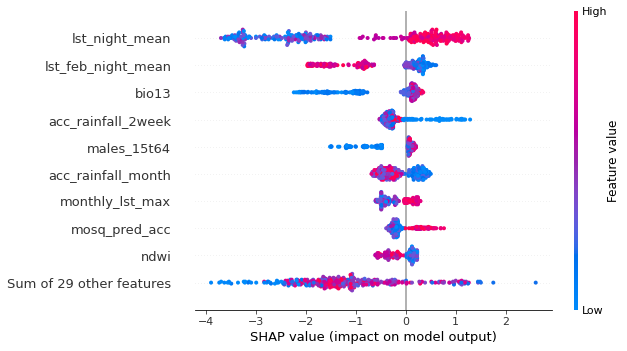

In [31]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=10)

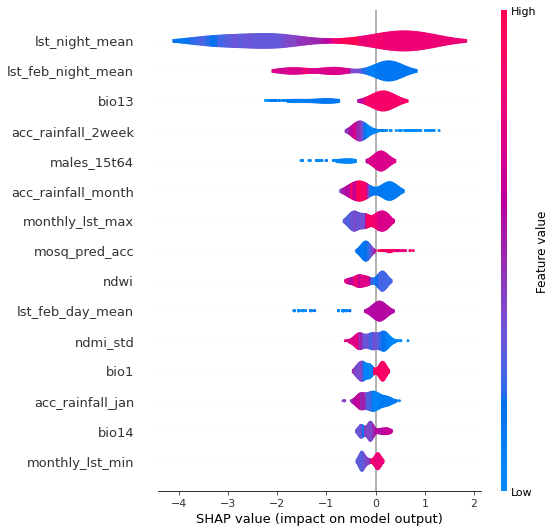

In [32]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin', max_display=15)

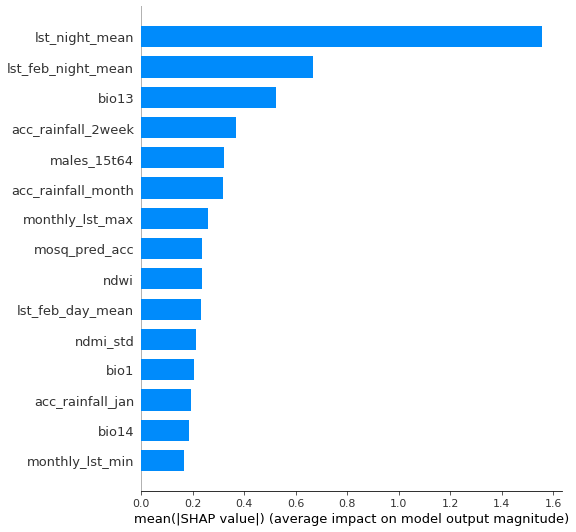

In [33]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='bar', max_display=15)

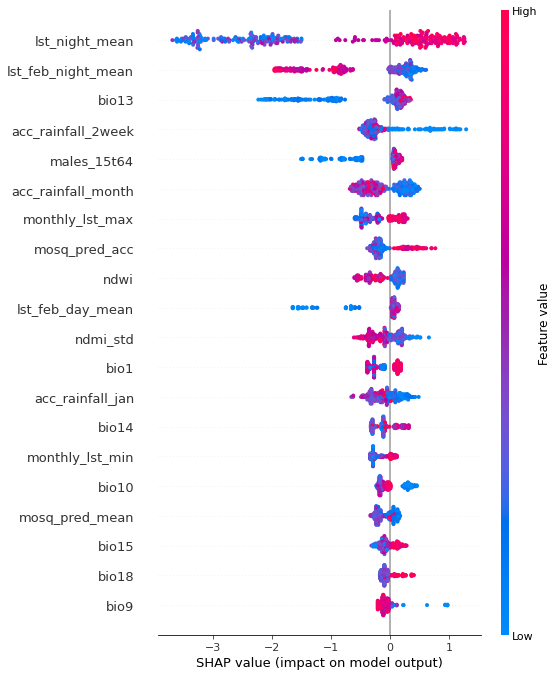

In [34]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=20)

In [35]:
shap_lim = (-3, 2)

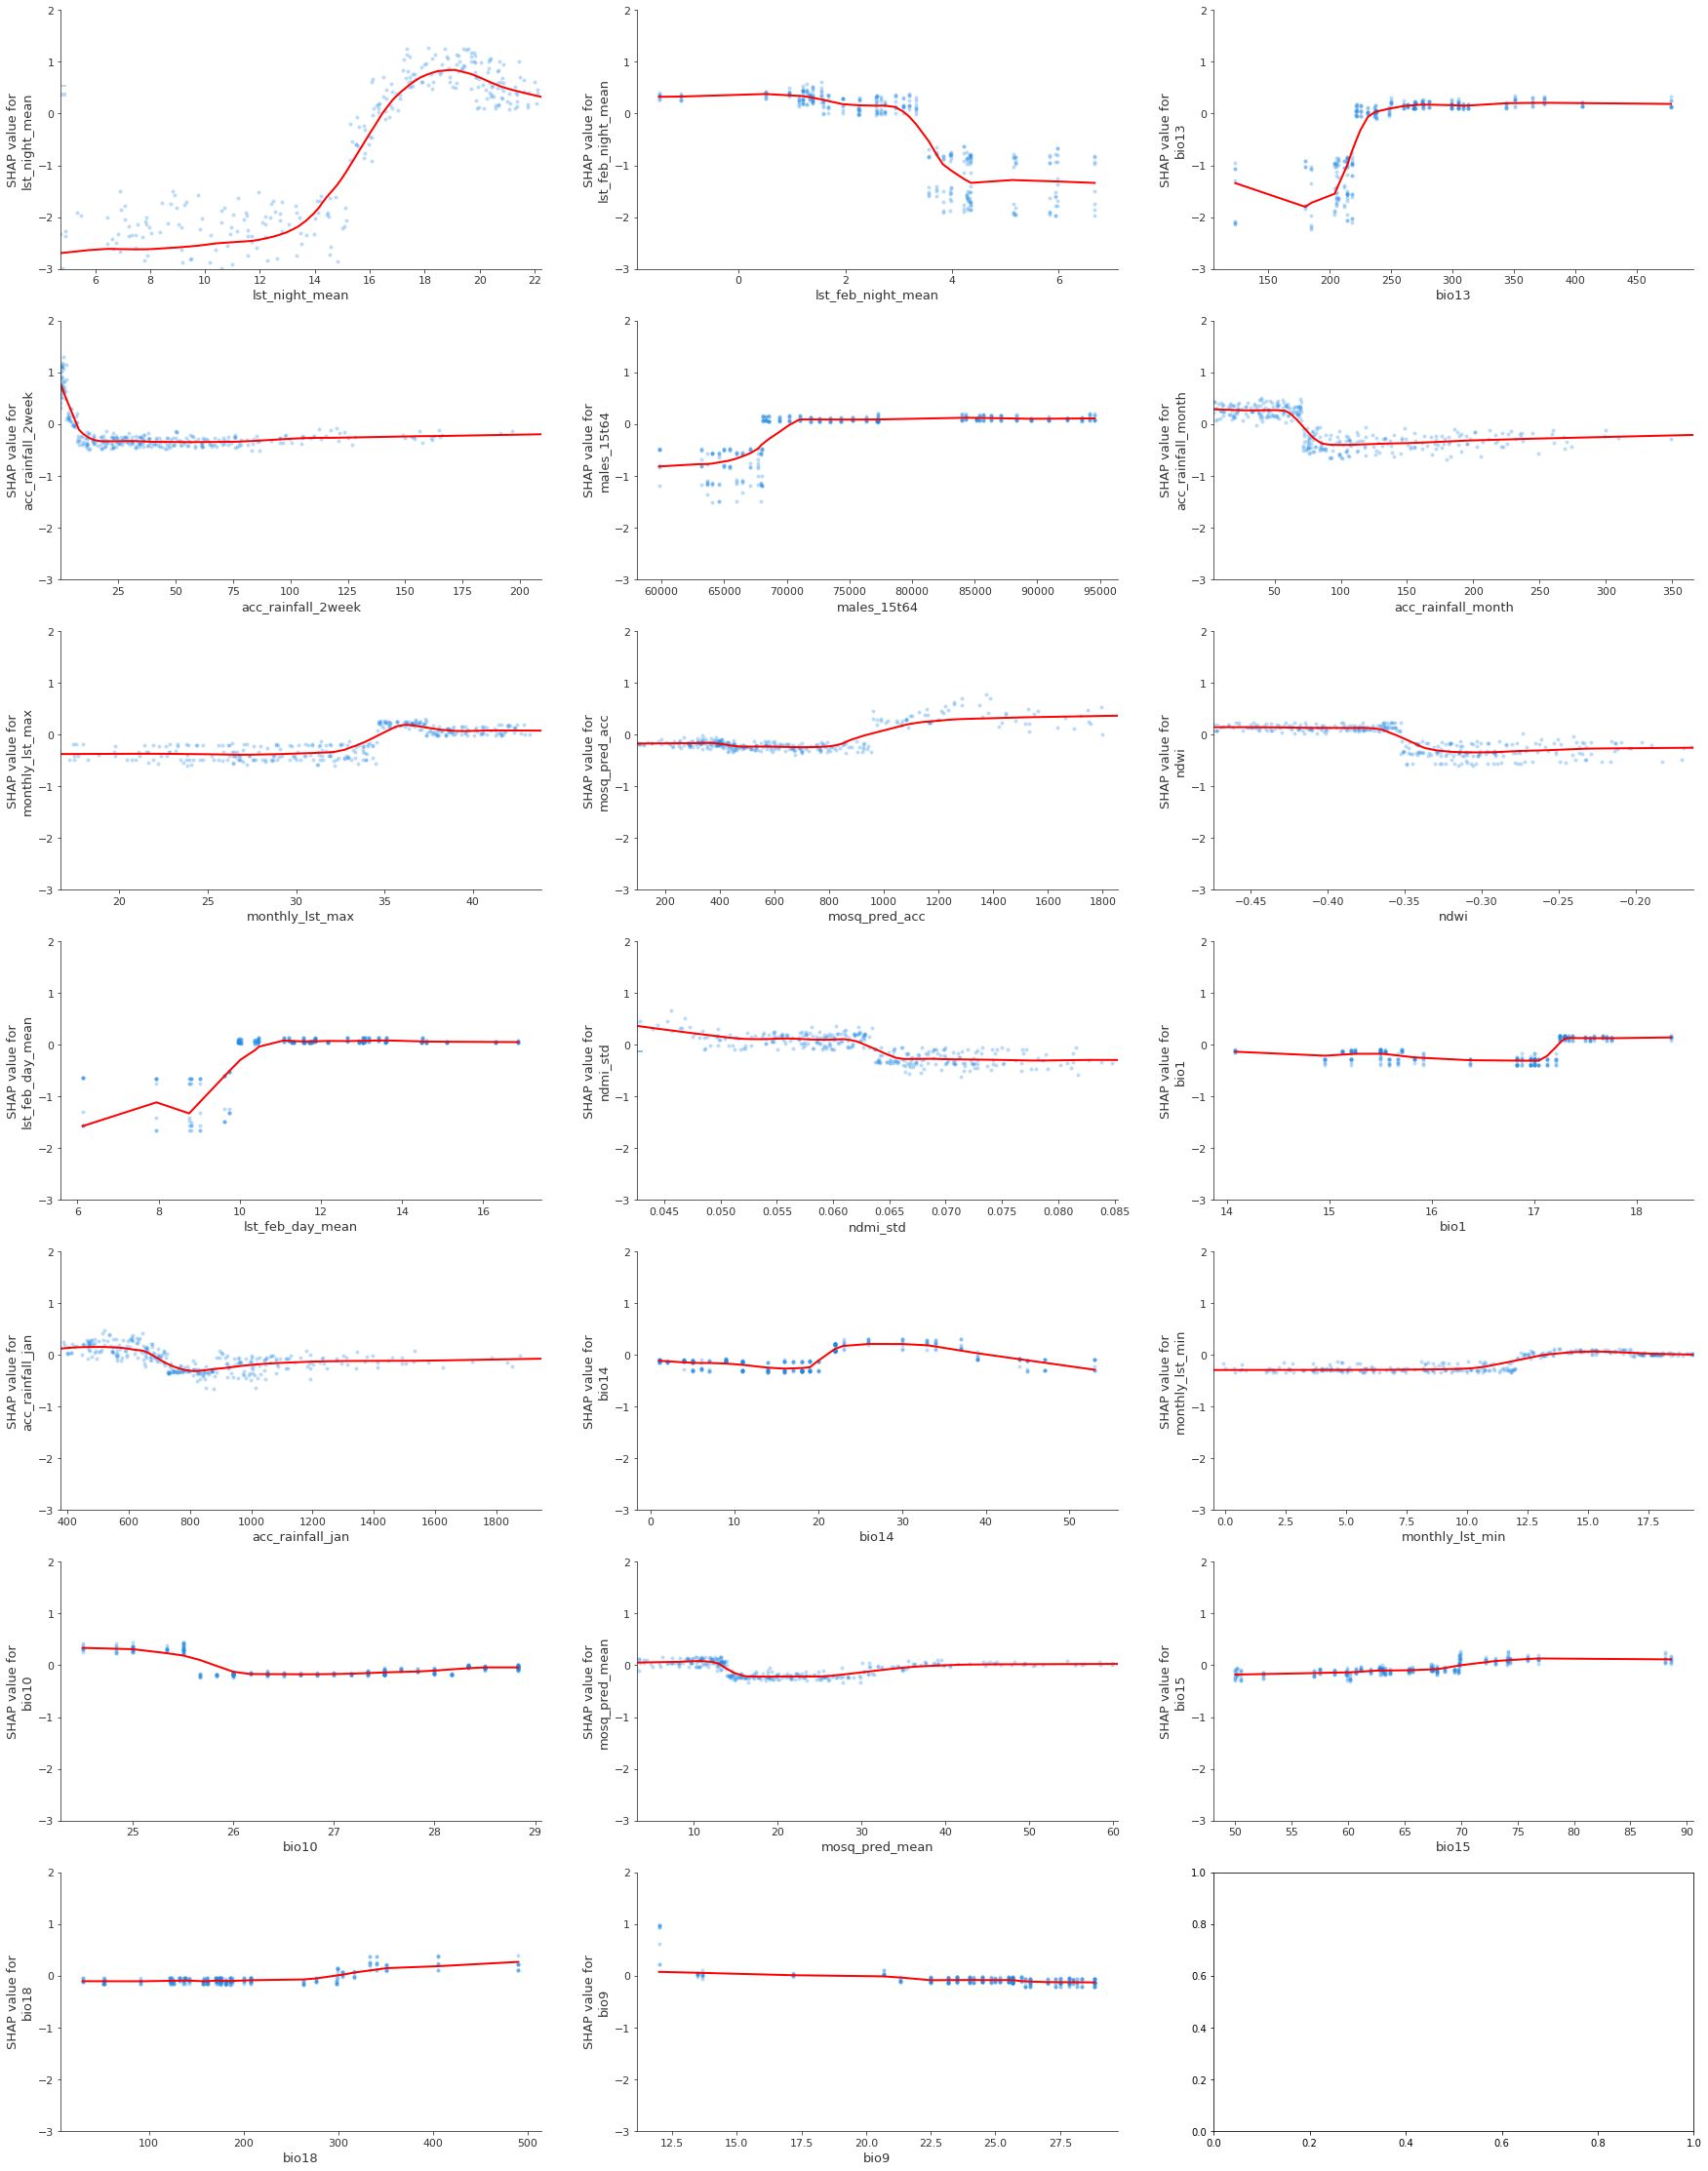

In [36]:
num_plots = 20

fig, axes = plt.subplots(7, 3, figsize=(30, 40))  # Adjust figsize as needed
i = 0

for ft in sorted_mean_abs_values_idx[:num_plots]:
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = data.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2, frac=.3)
    
    ax.plot(*list(zip(*lowess)), color="red", lw=2)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values, features=data, 
                         feature_names=feature_names, interaction_index=None, 
                         xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax=ax, show = False)
    
    i = i+1

plt.show()

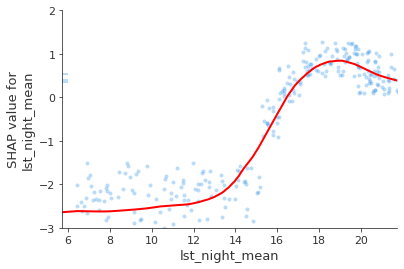

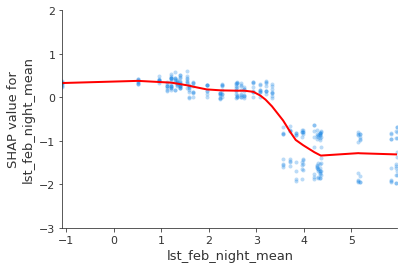

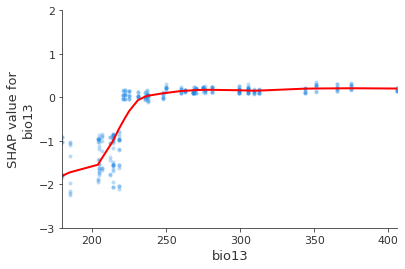

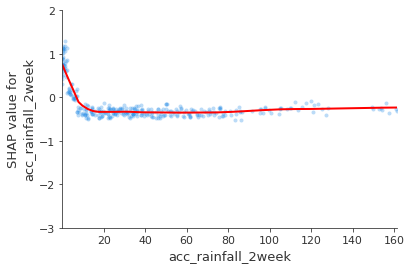

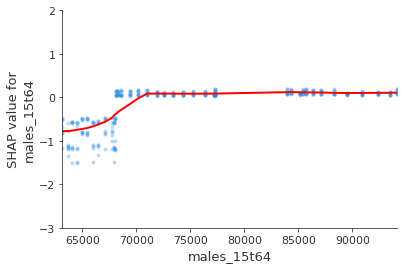

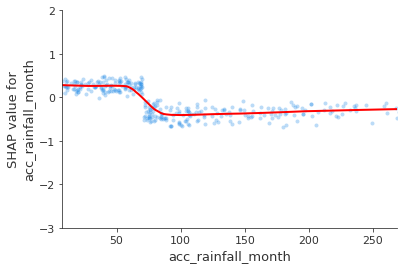

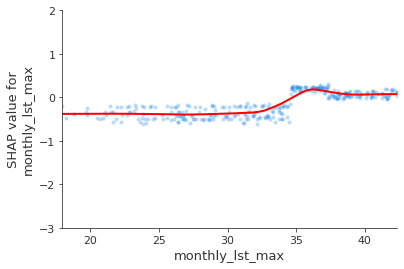

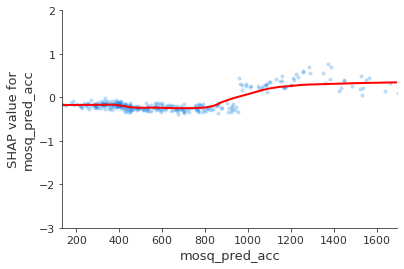

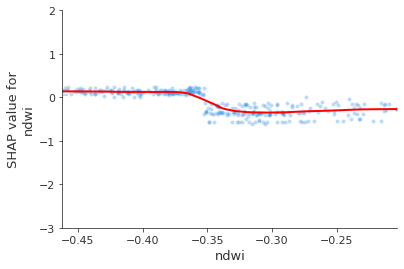

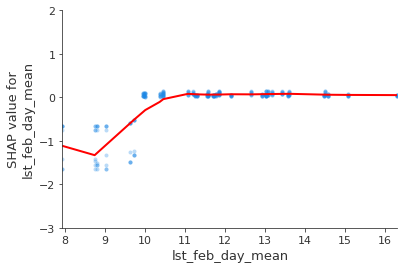

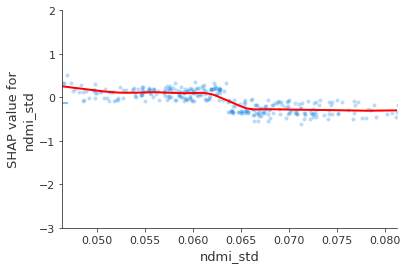

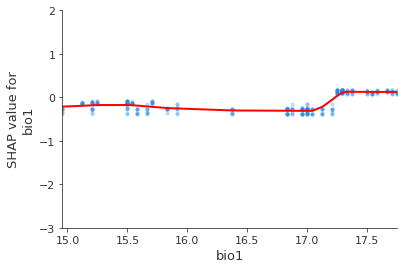

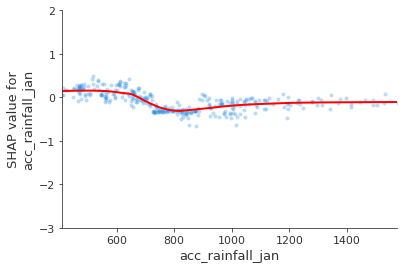

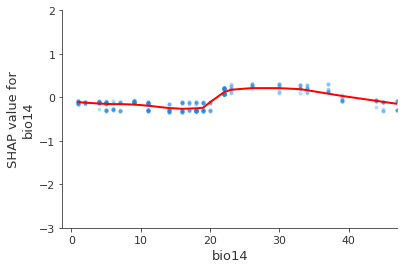

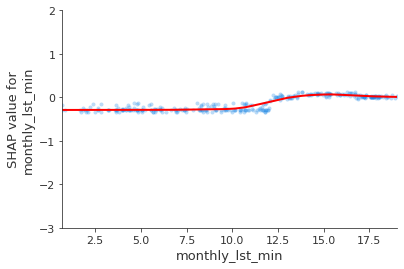

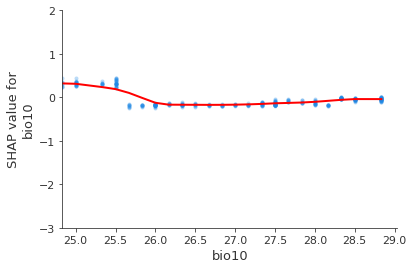

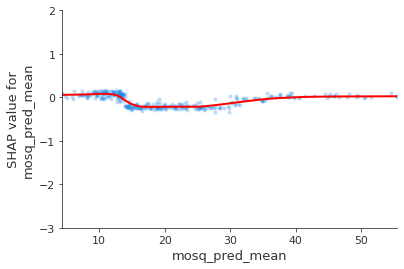

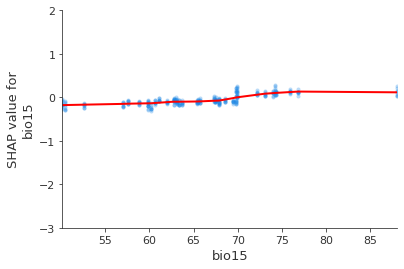

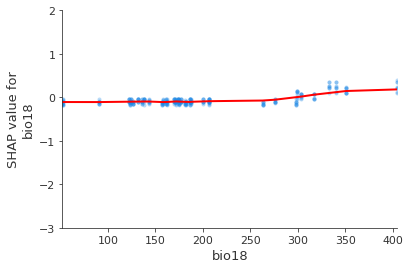

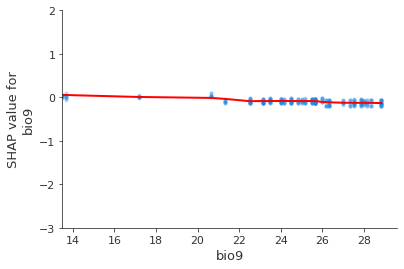

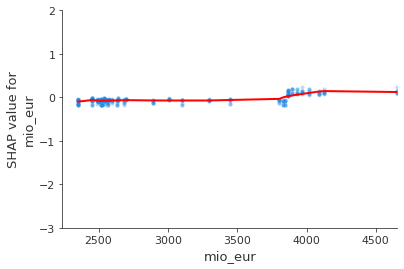

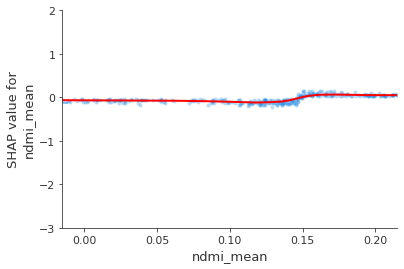

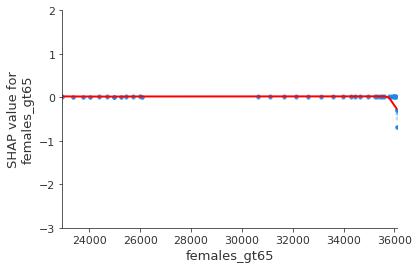

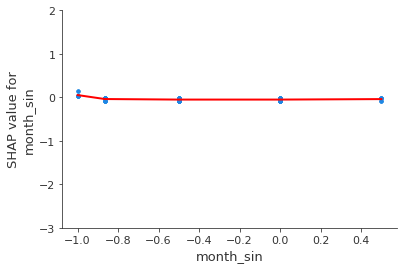

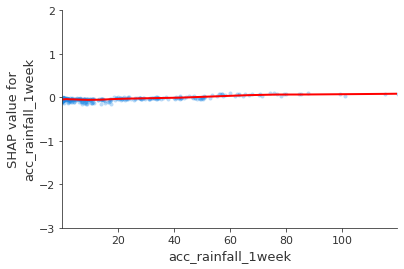

In [37]:
for ft in sorted_mean_abs_values_idx[:25]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(3)", xmax="percentile(97)", alpha=0.3, ax = ax)